In [4]:
from pathlib import Path
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import dask
from dask.distributed import Client, LocalCluster

dask.config.set({"distributed.dashboard.link": "/proxy/{port}/status"})
cluster = LocalCluster(n_workers=64, threads_per_worker = 1)
client = Client(cluster)

BASE = Path("../data")

PATH_WBT  = BASE / "DailyMax-WBT"
PATH_HI   = BASE / "hi"
PATH_WBGT = BASE / "wbgt"
PATH_UTCI = BASE / "utci_daily"
PATH_SST  = BASE / "sea_surface_temperature_arabia"


/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43589 instead
  warnings.warn(


Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...

Multi-year JJAS Dubai summary:
                                time         year        SST_C        WBT_C  \
count                           2797  2797.000000  2797.000000  2797.000000   
mean   2011-08-03 09:48:58.434036224  2011.006793    32.878956    28.426259   
min              2000-06-01 00:00:00  2000.000000    29.432114    22.404903   
25%              2005-08-29 00:00:00  2005.000000    32.354820    27.655940   
50%              2011-08-03 00:00:00  2011.000000    33.070053    28.575157   
75%              2017-07-02 00:00:00  2017.000000    33.5

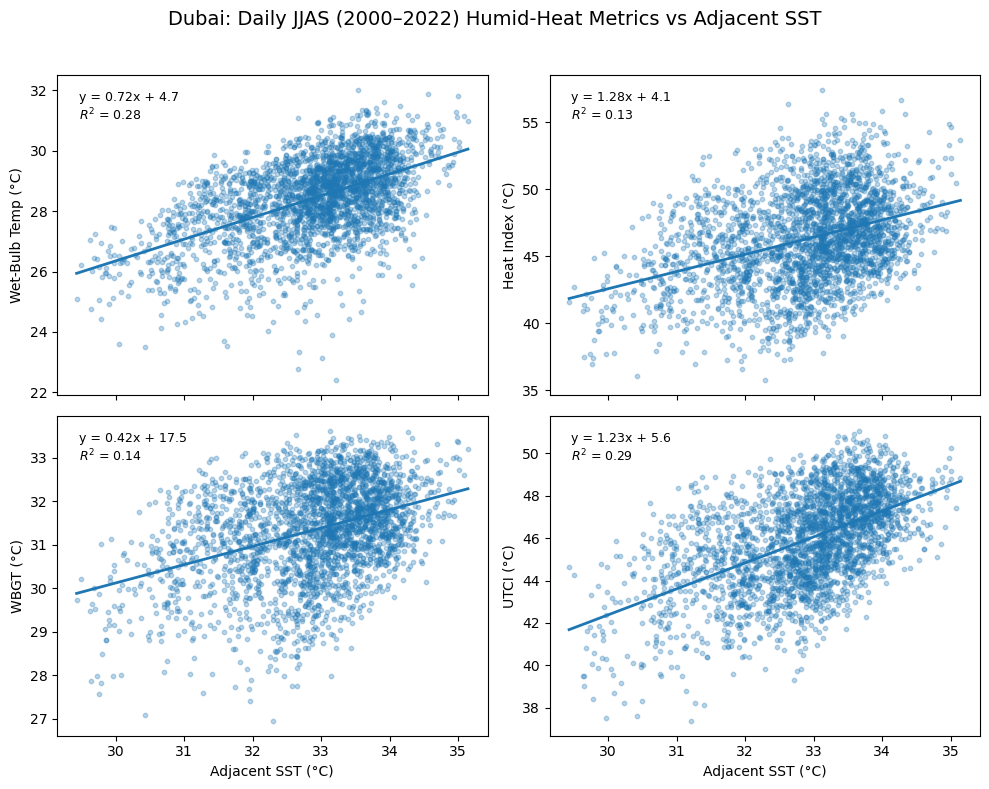

In [5]:

# ------------------ City Coordinates ------------------
CITIES = {
    "Dubai":       (25.2048, 55.2708),
    "Doha":        (25.2854, 51.5310),
    "Aden":        (12.7855, 45.0187),
    "Muscat":      (23.6150, 58.5453),
    "Jeddah":      (21.4858, 39.1925),
    "Al_Hudaydah": (14.7978, 42.9530),
}

# example usage:
city_name = "Dubai"
CITY_LAT, CITY_LON = CITIES[city_name]

CITY_RADIUS_KM = 30.0   # land HH metrics
SST_RADIUS_KM  = 50.0   # adjacent SST

YEARS = range(2000, 2023)  # 2000–2022 inclusive
JJAS_MONTHS = [6, 7, 8, 9]

FILL_THRESHOLD = -100.0  # anything below this is obviously bogus


# ---------------- helpers ----------------
def clean_temp_c(da):
    da = da.where(da > FILL_THRESHOLD)
    da.attrs["units"] = "degC"
    return da

def clean_wbt(da):
    """Clean WBT specifically: mask bogus low values, then enforce WBT >= 0."""
    da = da.where(da > FILL_THRESHOLD)
    da = da.where(da >= 0)      
    da.attrs["units"] = "degC"
    return da

def clean_temp_k_to_c(da):
    da_c = da - 273.15
    da_c.attrs["units"] = "degC"
    da_c = da_c.where(da_c > FILL_THRESHOLD)
    return da_c


def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between (lat1, lon1) and (lat2, lon2), km."""
    R = 6371.0
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


def city_mean_series(da, city_lat, city_lon, radius_km):
    """
    Given a DataArray da(time, lat, lon), return a 1D time series of the mean
    over all grid cells within radius_km of (city_lat, city_lon).
    """
    # broadcast in (lat, lon) so dims line up
    lat2d, lon2d = xr.broadcast(da["lat"], da["lon"])  # (lat, lon)

    # dist is a DataArray with dims (lat, lon)
    dist = haversine_distance_km(lat2d, lon2d, city_lat, city_lon)

    mask = dist <= radius_km  # boolean DataArray (lat, lon)
    da_city = da.where(mask)

    return da_city.mean(dim=("lat", "lon"), skipna=True)


# ---------------- yearly open functions ----------------
def open_wbt_year(year):
    fn = PATH_WBT / f"DailyMax-WBT-{year}.nc"
    ds = xr.open_dataset(fn)
    da = ds["twx"]  # (time, latitude, longitude), °C, global

    # subset to AP-ish box
    da = da.sel(
        longitude=slice(30.0, 65.0),
        latitude=slice(40.0, 5.0),  # global lat is descending
    )
    da = da.rename(latitude="lat", longitude="lon")
    da = clean_wbt(da)
    return da


def open_hi_year(year):
    fn = PATH_HI / f"hi_AP_{year}.nc"
    ds = xr.open_dataset(fn)
    da = ds["hi"]  # (time, y, x)
    da = da.rename(y="lat", x="lon")
    da = clean_temp_c(da)
    return da


def open_wbgt_year(year):
    fn = PATH_WBGT / f"wbgt_AP_{year}.nc"
    ds = xr.open_dataset(fn)
    da = ds["wbgt"]  # (time, y, x)
    da = da.rename(y="lat", x="lon")
    da = clean_temp_c(da)
    return da


def open_utci_year(year):
    files = sorted(PATH_UTCI.glob(f"era5heat_utci_max_{year}_*.nc"))
    if not files:
        raise FileNotFoundError(f"No UTCI files for year {year}")
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds["utci_max"]  # (time, lat, lon), K
    da = clean_temp_k_to_c(da)
    return da


def open_sst_year(year):
    files = sorted(PATH_SST.glob(f"era5_sst_daily_mean_ap_{year}_*.nc"))
    if not files:
        raise FileNotFoundError(f"No SST files for year {year}")
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds["sst"]  # (valid_time, latitude, longitude), K
    da = da.rename(valid_time="time", latitude="lat", longitude="lon")
    da = clean_temp_k_to_c(da)
    return da


# ---------------- loop over years, build city time series ----------------
records = []

for year in YEARS:
    print(f"Processing {year}...")
    wbt_y  = open_wbt_year(year)
    hi_y   = open_hi_year(year)
    wbgt_y = open_wbgt_year(year)
    utci_y = open_utci_year(year)
    sst_y  = open_sst_year(year)

    # JJAS slice
    wbt_j = wbt_y.sel(time=wbt_y.time.dt.month.isin(JJAS_MONTHS))
    hi_j  = hi_y.sel(time=hi_y.time.dt.month.isin(JJAS_MONTHS))
    wbgt_j = wbgt_y.sel(time=wbgt_y.time.dt.month.isin(JJAS_MONTHS))
    utci_j = utci_y.sel(time=utci_y.time.dt.month.isin(JJAS_MONTHS))
    sst_j  = sst_y.sel(time=sst_y.time.dt.month.isin(JJAS_MONTHS))

    # intersect times within this year
    times_common = (
        pd.Index(wbt_j.time.values)
        .intersection(hi_j.time.values)
        .intersection(wbgt_j.time.values)
        .intersection(utci_j.time.values)
        .intersection(sst_j.time.values)
    )
    times_common = times_common.sort_values()

    if len(times_common) == 0:
        print(f"  -> No overlapping JJAS days in {year}, skipping.")
        continue

    wbt_j = wbt_j.sel(time=times_common)
    hi_j  = hi_j.sel(time=times_common)
    wbgt_j = wbgt_j.sel(time=times_common)
    utci_j = utci_j.sel(time=times_common)
    sst_j  = sst_j.sel(time=times_common)

    # city & SST neighborhood means
    wbt_city  = city_mean_series(wbt_j,  CITY_LAT, CITY_LON, CITY_RADIUS_KM)
    hi_city   = city_mean_series(hi_j,   CITY_LAT, CITY_LON, CITY_RADIUS_KM)
    wbgt_city = city_mean_series(wbgt_j, CITY_LAT, CITY_LON, CITY_RADIUS_KM)
    utci_city = city_mean_series(utci_j, CITY_LAT, CITY_LON, CITY_RADIUS_KM)
    sst_city  = city_mean_series(sst_j,  CITY_LAT, CITY_LON, SST_RADIUS_KM)

    df_year = pd.DataFrame({
        "time": times_common,
        "year": year,
        "SST_C":  sst_city.values,
        "WBT_C":  wbt_city.values,
        "HI_C":   hi_city.values,
        "WBGT_C": wbgt_city.values,
        "UTCI_C": utci_city.values,
    })

    records.append(df_year)

# concat all years
df = pd.concat(records, ignore_index=True).dropna()
print(f"\nMulti-year JJAS {city_name} summary:")
print(df.describe())
print(f"Total JJAS days: {len(df)}")


# ---------------- regression + plotting ----------------
def fit_line(x, y):
    """Return slope, intercept, and R^2 of a simple linear regression."""
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 2:
        return np.nan, np.nan, np.nan

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return m, b, r2


metrics = [
    ("WBT_C",  "Wet-Bulb Temp (°C)"),
    ("HI_C",   "Heat Index (°C)"),
    ("WBGT_C", "WBGT (°C)"),
    ("UTCI_C", "UTCI (°C)"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.ravel()

x = df["SST_C"].values

for ax, (col, label) in zip(axes, metrics):
    y = df[col].values
    m, b, r2 = fit_line(x, y)

    # scatter (multi-year)
    sc = ax.scatter(x, y, alpha=0.3, s=10)

    if np.isfinite(m):
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, linewidth=2)

        ax.text(
            0.05, 0.95,
            f"y = {m:.2f}x + {b:.1f}\n$R^2$ = {r2:.2f}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    ax.set_ylabel(label)

axes[2].set_xlabel("Adjacent SST (°C)")
axes[3].set_xlabel("Adjacent SST (°C)")

fig.suptitle(f"{city_name}: Daily JJAS (2000–2022) Humid-Heat Metrics vs Adjacent SST", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

